In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import glob
import os
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, Patch
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection
from matplotlib.container import ErrorbarContainer


In [2]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
n_best=2440
schu=xr.open_dataset("../../FesmData/Schumacher2018_GIA_GrIS/data/schumacher2018_GR.nc")
yelmo=xr.open_dataset("../output/ensemble_gia.nc")
present = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")

best = yelmo.sel(sim=n_best)

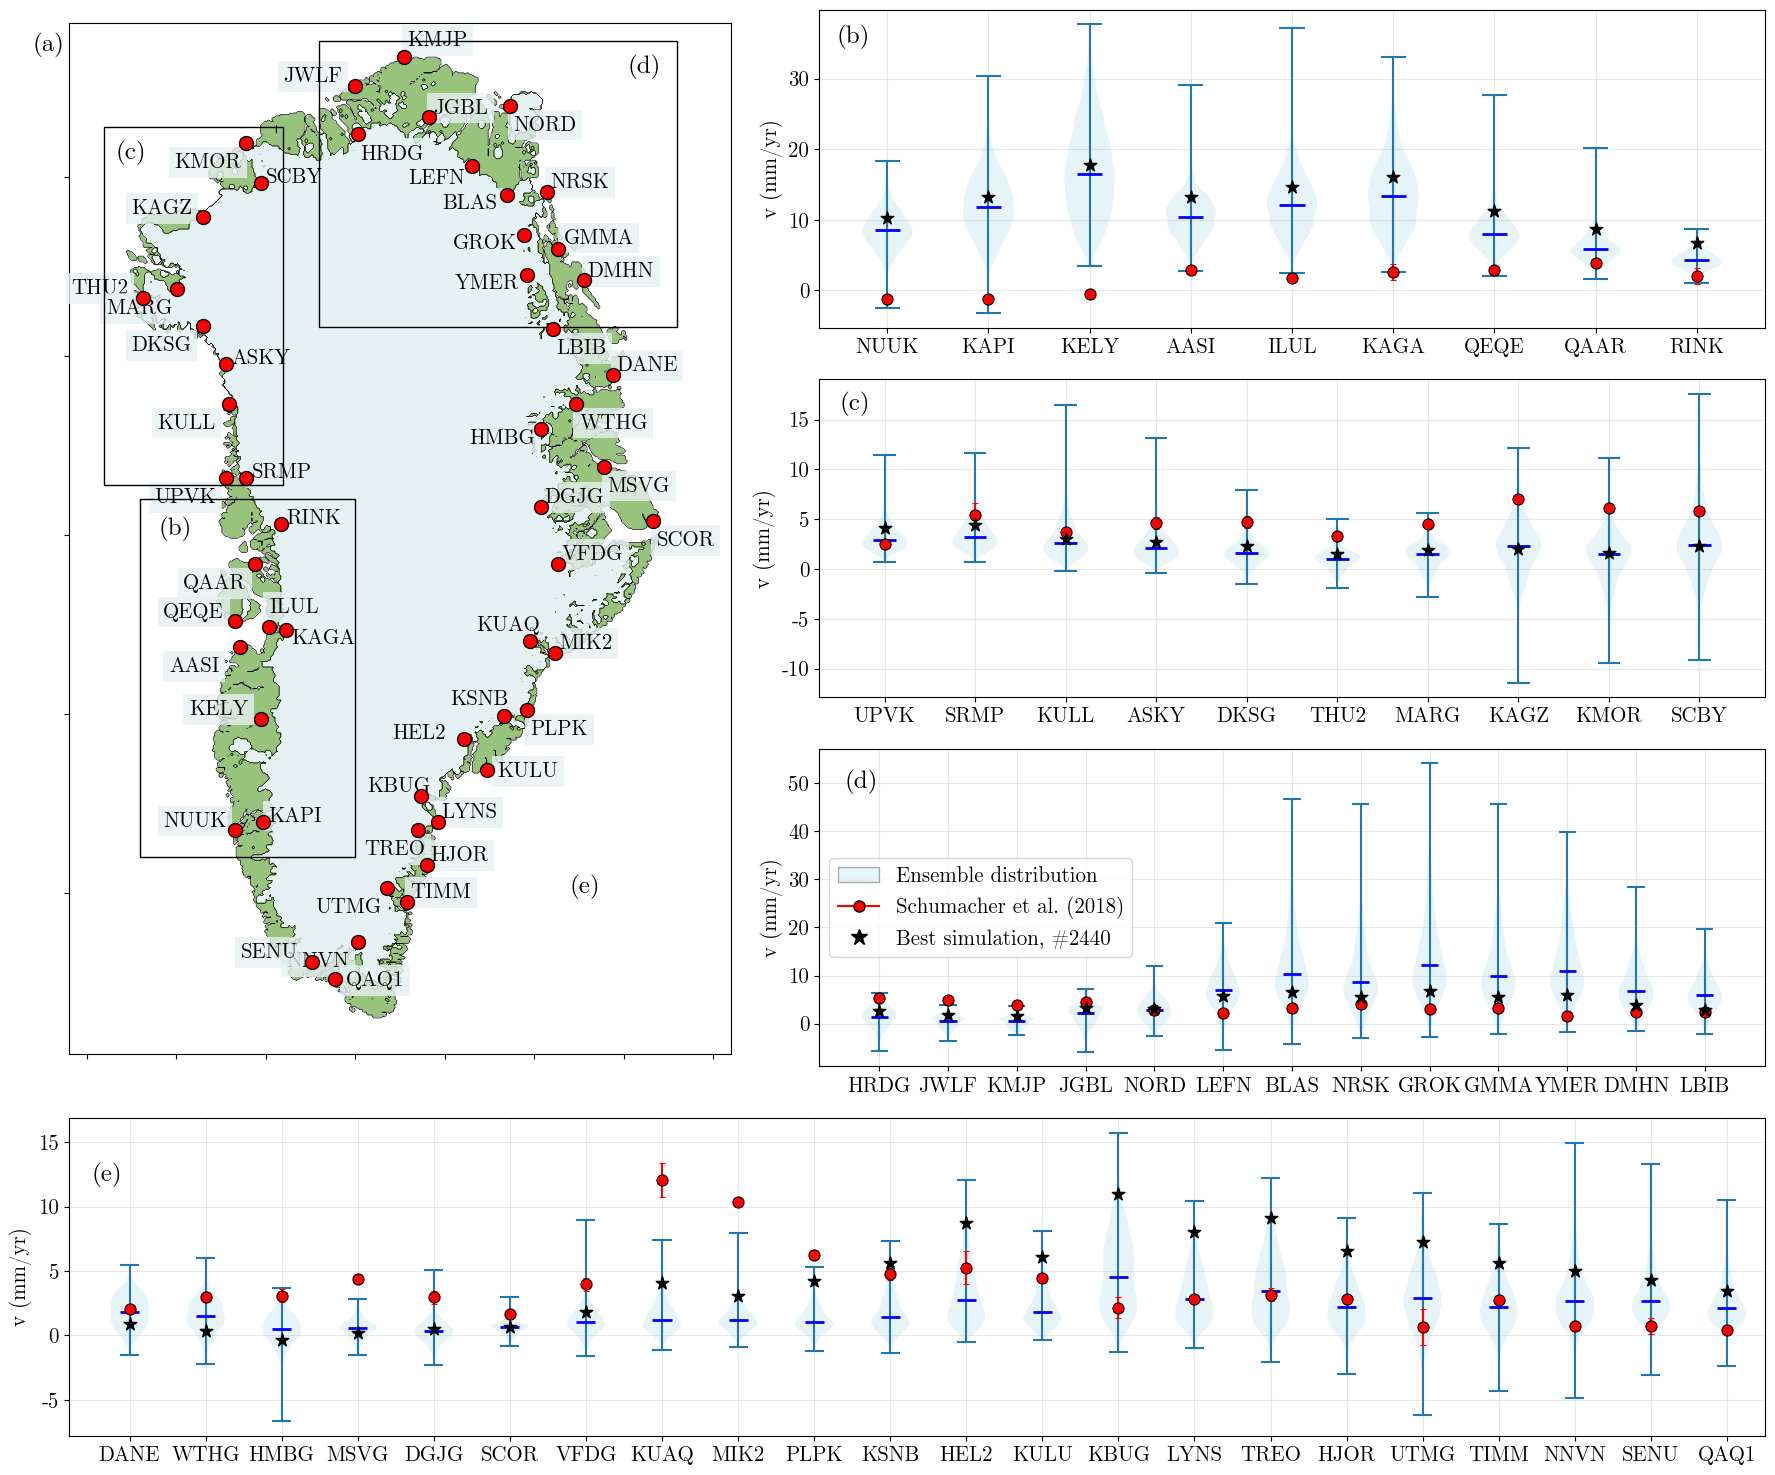

In [3]:
def fig_locations(ax,schu,f):
    # Figure Location of GIA stations
    present1=xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-4KM/GRL-4KM_TOPO-M17.nc")
    present=present1.where((present1.xc<900)&(present1.yc<present1.xc*0.75-650))

    # Mapa fondo --------------------------------------------
    ax.set_facecolor("white")
    ax.contour(present.xc, present.yc, present.z_srf, levels=np.linspace(0,10,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(present.xc, present.yc, present.z_srf.where(present.z_srf>-10), colors="#98C37C",zorder=1)
    xmin=-800
    xmax=1050
    mask = np.where(np.isnan(present.z_srf), 0, present.z_srf)
    mask = np.where(mask == 0, 1, np.nan)
    ny = mask.shape[0]
    xc = present.xc.values
    zeros_left = np.ones((ny, 1))
    zeros_right = np.ones((ny, 1))
    mask_extended = np.hstack([zeros_left, mask, zeros_right])
    xc_extended = np.concatenate([[xmin], xc, [xmax]])
    ax.contourf(xc_extended, present.yc, mask_extended,colors="white",zorder=2)
    ax.contour(present.xc, present.yc, present.H_ice, levels=np.linspace(0,10,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(present.xc, present.yc, present.H_ice.where(present.H_ice>0), levels=np.linspace(0,4000,2), colors="#E6F1F3",zorder=3)


    # Estaciones --------------------------------------------
    i=0
    for station in schu.station.values:
        sim=schu.sel(station=station)
        grey_statopns=[]
        if station in grey_statopns:
            ax.plot(sim.xc, sim.yc, 'o', color="grey", markersize=10, markeredgecolor='black', label=station,zorder=6)  
        else:
            ax.plot(sim.xc, sim.yc, 'o', color="red", markersize=10, markeredgecolor='black', label=station,zorder=6)  
        if sim.xc<100:
            a=-200
        else:
            a=10
        if i%2==0:
            b=10
        else:
            b=-70    
        if station=="TREO":a=-150
        if station=="KBUG":a, b=-150, 10
        if station=="LEFN":a, b=-180, -50
        if station=="HRDG":a=8
        if station=="KMJP":b=30
        if station=="BLAS":a, b=-180,-40
        if station=="GROK":a, b=-200,-40
        if station=="YMER":a, b=-200,-40
        if station=="HMBG":a, b=-200,-40
        if station=="KAGA":a, b=15,-40
        if station=="ILUL":a, b=0,40
        if station in ["RINK","SRMP","SCBY","ASKY","KAPI"]:a, b=15,0
        if station=="GMMA":a, b=15,15
        if station=="HEL2":a, b=-200,0
        if station=="KULU":a, b=30,-20
        if station=="QAQ1":a, b=30,-20
        if station in ["KUAQ","KSNB"]:a, b=-150,30

        ax.text(sim.xc+a, sim.yc+b, station, color="black", fontsize=f, zorder=5,
                bbox=dict(facecolor='#E6F1F3',edgecolor='none',alpha=0.8))
        i=i+1

    rect = Rectangle((-600,-2900), 600, 1000, facecolor='none', edgecolor="black",zorder=5)
    ax.add_patch(rect)
    rect = Rectangle((-700,-1860), 500, 1000, facecolor='none', edgecolor="black",zorder=5)
    ax.add_patch(rect)
    rect = Rectangle((-100,-1420), 1000, 800, facecolor='none', edgecolor="black",zorder=5)
    ax.add_patch(rect)
        
    ax.set_xlim(xmin,xmax)
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return

# ------------------------------------------------
# Figure
# ------------------------------------------------
fig = plt.figure(figsize=(18, 15))
gs = GridSpec(4, 2, figure=fig, width_ratios=[7, 10])  # primera columna más estrecha

ax_side = fig.add_subplot(gs[0:3, 0])
ax_main1 = fig.add_subplot(gs[0, 1])
ax_main2 = fig.add_subplot(gs[1, 1])
ax_main3 = fig.add_subplot(gs[2, 1])
ax_main4 = fig.add_subplot(gs[3, :])

axs = [ax_main1, ax_main2, ax_main3, ax_main4]

# Datos
station_ranges = [(0,9), (9,19), (19,32), (32,54)]
stations = schu.station.values
data_for_violin = [yelmo.v_vert.sel(station=sta).values for sta in stations]
best_v = [best.v_vert.sel(station=sta).values for sta in stations]

for ax, (a,b) in zip(axs, station_ranges):
    # Ensemble
    vp = ax.violinplot(data_for_violin[a:b],positions=np.arange(a, b),showmedians=True,showextrema=True,
        showmeans=False)
    for body in vp['bodies']:
        body.set_facecolor('lightblue')
        body.set_alpha(0.3)
    vp['cmedians'].set_color('blue')
    vp['cmedians'].set_linewidth(2)

    # Schumacher data
    ax.errorbar(np.arange(a, b),schu.v_vert.values[a:b],yerr=schu["std"].values[a:b],fmt='o',color='red',
        ecolor='red',markersize=8,markerfacecolor='red',markeredgecolor='black',markeredgewidth=0.8,capsize=2,zorder=60)
    
    # Best simulation
    ax.scatter(np.arange(a, b), best_v[a:b], s=90, marker="*", color="black",zorder=61)
    
    # General features
    ax.grid(alpha=0.3)
    ax.set_ylabel("v (mm/yr)")
    ax.set_xticks(np.arange(a,b))
    ax.set_xticklabels(stations[a:b], rotation=0)

# Stations map
f=18
fig_locations(ax_side,schu,f-3)

# axs labels
ax_side.text(-900,-650,"(a)",fontsize=f)
ax_side.text(-550,-2000,"(b)",fontsize=f)
ax_side.text(-670,-950,"(c)",fontsize=f)
ax_side.text(760,-710,"(d)",fontsize=f)
ax_side.text(600,-3000,"(e)",fontsize=f)
axs[0].text(-0.5,35,"(b)",fontsize=f)
axs[1].text(9-0.5,16,"(c)",fontsize=f)
axs[2].text(19-0.5,49,"(d)",fontsize=f)
axs[3].text(32-0.5,12,"(e)",fontsize=f)
axs[3].set_xlim(31.2,53.5)

# Legend
violin_proxy = Rectangle((0,0), 1, 1,facecolor='lightblue',edgecolor='black',alpha=0.3,label='Ensemble distribution')
point = mlines.Line2D([], [],color='red',marker='o',markersize=8,markerfacecolor='red',markeredgecolor='black')
err_lines = LineCollection([[(0, -0.5), (0, 0.5)]],colors='red')
errorbar_proxy = ErrorbarContainer((point, [err_lines], [err_lines]),label='Schumacher et al. (2018)')
star_proxy = mlines.Line2D([], [],color='black',marker='*',markersize=12,linestyle='none',label='Best simulation, #'+str(n_best))
axs[2].legend(handles=[violin_proxy, errorbar_proxy, star_proxy],
              loc='center left')
plt.tight_layout()


In [4]:
fig.savefig(f"../figs/ensemble_gia_{n_best}.png", dpi=300)
